In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.ensemble import RandomForestRegressor
from scipy.signal import savgol_filter

In [2]:
DATA_PATH = "aved_raw.csv"

df_raw = pd.read_csv(DATA_PATH)
print("Raw shape:", df_raw.shape)

# --- Parse time safely ---
# NOTE FOR STUDENTS:
# Using utc=True makes mixed time-zone strings consistent and avoids future pandas errors.

df_raw["time"] = pd.to_datetime(df_raw["time"], errors="coerce", utc=True)

nat_count = int(df_raw["time"].isna().sum())
print("Unparseable timestamps (NaT):", nat_count)

df_raw = df_raw.set_index("time").sort_index()

print("After time parsing:", df_raw.shape)
df_raw.head()

Raw shape: (906815, 49)
Unparseable timestamps (NaT): 0
After time parsing: (906815, 48)


,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value,BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality,BIOLOGY.LINE 3 TANK 1.N2O value,BIOLOGY.LINE 3 TANK 1.N2O quality,BIOLOGY.LINE 3 TANK 1.NH4 value,BIOLOGY.LINE 3 TANK 1.NH4 quality,BIOLOGY.LINE 3 TANK 1.NO3 value,BIOLOGY.LINE 3 TANK 1.NO3 quality,...,BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK value,BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK quality,BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK value,BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK quality,BIOLOGY.LINE 3 TANK 1.PO4 value,BIOLOGY.LINE 3 TANK 1.PO4 quality,INLET.Q value,INLET.Q quality,INLET.STATE.SWM INLET FLOW value,INLET.STATE.SWM INLET FLOW quality
time,,,,,,,,,,,,,,,,,,,,,
2022-06-11 22:01:00+00:00,26829.375000,1.0,NaN,NaN,0.700231,0.0,1.66608,0.0,0.074907,0.0,...,NaN,NaN,NaN,NaN,0.285834,1.0,NaN,NaN,NaN,NaN
2022-06-11 22:02:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
2022-06-11 22:03:00+00:00,29626.341797,1.0,NaN,NaN,0.697917,0.0,1.52727,0.0,0.074907,0.0,...,NaN,NaN,NaN,NaN,0.273499,1.0,NaN,NaN,NaN,NaN
2022-06-11 22:04:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
2022-06-11 22:05:00+00:00,28605.208984,1.0,NaN,NaN,0.656829,0.0,1.43633,0.0,0.056901,0.0,...,NaN,NaN,NaN,NaN,0.273499,1.0,NaN,NaN,NaN,NaN


# Select variables (ALL From TANK 1)

In [3]:
# --- Step 2: Select All Tank 1 Features ---

# Explicitly selecting all "value" columns for Tank 1
df_vars = df_raw[
    [
        "BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value",
        "BIOLOGY.LINE 3 TANK 1.N2O value",
        "BIOLOGY.LINE 3 TANK 1.NH4 value",
        "BIOLOGY.LINE 3 TANK 1.NO3 value",
        "BIOLOGY.LINE 3 TANK 1.O2 value",
        "BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value",
        "BIOLOGY.LINE 3 TANK 1.PROCESSPHASE value",
        "BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value",
        "BIOLOGY.LINE 3 TANK 1.SS value",
        "BIOLOGY.LINE 3 TANK 1.TEMPERATURE value",
        "BIOLOGY.LINE 3 TANK 1.PO4 value"
    ]
].copy()

# Rename columns to standard names for cleaner plots during your EDA
df_vars.columns = [
    "VALVE 1 PCT", 
    "N2O", 
    "NH4", 
    "NO3", 
    "O2", 
    "O2 SETPOINT", 
    "PROCESS PHASE", 
    "AIRFLOW", 
    "SS (Suspended Solids)", 
    "TEMPERATURE", 
    "PO4"
]

print(f"Selected {df_vars.shape[1]} features for Tank 1.")
df_vars.head()

Selected 11 features for Tank 1.


,VALVE 1 PCT,N2O,NH4,NO3,O2,O2 SETPOINT,PROCESS PHASE,AIRFLOW,SS (Suspended Solids),TEMPERATURE,PO4
time,,,,,,,,,,,
2022-06-11 22:01:00+00:00,NaN,0.700231,1.66608,0.074907,0.058955,NaN,2.0,NaN,1.525374,NaN,0.285834
2022-06-11 22:02:00+00:00,NaN,NaN,NaN,NaN,NaN,1.238239,NaN,NaN,NaN,NaN,NaN
2022-06-11 22:03:00+00:00,NaN,0.697917,1.52727,0.074907,0.079933,NaN,2.0,NaN,1.536805,NaN,0.273499
2022-06-11 22:04:00+00:00,NaN,NaN,NaN,NaN,NaN,1.154271,NaN,NaN,NaN,NaN,NaN
2022-06-11 22:05:00+00:00,NaN,0.656829,1.43633,0.056901,0.330223,NaN,2.0,NaN,1.509847,NaN,0.273499


# DUPLICATES

In [4]:
df = df_vars.copy()

# 1) Exact duplicate rows (all variables identical)
exact_dups = df.duplicated()
print("Exact duplicate rows:", int(exact_dups.sum()))

# Drop exact duplicates
df = df[~exact_dups].copy()

# 2) Duplicate timestamps (same time index)
time_dups = df.index.duplicated()
print("Duplicate timestamps:", int(time_dups.sum()))

# Drop duplicate timestamps, keeping the FIRST occurrence
df = df[~df.index.duplicated(keep="first")].copy()

print("Shape after dropping duplicates:", df.shape)

df.head()

Exact duplicate rows: 172407
Duplicate timestamps: 0
Shape after dropping duplicates: (734408, 11)


,VALVE 1 PCT,N2O,NH4,NO3,O2,O2 SETPOINT,PROCESS PHASE,AIRFLOW,SS (Suspended Solids),TEMPERATURE,PO4
time,,,,,,,,,,,
2022-06-11 22:01:00+00:00,NaN,0.700231,1.66608,0.074907,0.058955,NaN,2.0,NaN,1.525374,NaN,0.285834
2022-06-11 22:02:00+00:00,NaN,NaN,NaN,NaN,NaN,1.238239,NaN,NaN,NaN,NaN,NaN
2022-06-11 22:03:00+00:00,NaN,0.697917,1.52727,0.074907,0.079933,NaN,2.0,NaN,1.536805,NaN,0.273499
2022-06-11 22:04:00+00:00,NaN,NaN,NaN,NaN,NaN,1.154271,NaN,NaN,NaN,NaN,NaN
2022-06-11 22:05:00+00:00,NaN,0.656829,1.43633,0.056901,0.330223,NaN,2.0,NaN,1.509847,NaN,0.273499


# Structural & formatting errors (diagnose only)

In [10]:
# NOTE:
# Here we ONLY check formatting. We do not 'fix' values yet.
# We confirm: numeric types, missingness, sorted time index.

df_vars.info()

print("\nMissing values per variable:")
print(df_vars.isna().sum())

df_vars.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 906815 entries, 2022-06-11 22:01:00+00:00 to 2024-06-11 21:59:00+00:00
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VALVE 1 PCT            502835 non-null  float64
 1   N2O                    520546 non-null  float64
 2   NH4                    520595 non-null  float64
 3   NO3                    520583 non-null  float64
 4   O2                     520601 non-null  float64
 5   O2 SETPOINT            526285 non-null  float64
 6   PROCESS PHASE          519349 non-null  float64
 7   AIRFLOW                470203 non-null  float64
 8   SS (Suspended Solids)  520589 non-null  float64
 9   TEMPERATURE            506607 non-null  float64
 10  PO4                    520593 non-null  float64
dtypes: float64(11)
memory usage: 83.0 MB

Missing values per variable:
VALVE 1 PCT              403980
N2O                      386269
NH4               

,VALVE 1 PCT,N2O,NH4,NO3,O2,O2 SETPOINT,PROCESS PHASE,AIRFLOW,SS (Suspended Solids),TEMPERATURE,PO4
count,502835.000000,520546.000000,520595.000000,520583.000000,520601.000000,526285.000000,519349.000000,470203.000000,520589.000000,506607.000000,520593.000000
mean,44.468405,0.103827,2.307532,2.777697,0.615051,0.627683,1.501077,2188.748704,2.552868,15.659757,1.124619
std,42.042082,0.240844,2.209858,2.776430,0.612024,0.573422,0.583287,2133.804365,0.862651,3.380248,0.963480
min,0.000000,-0.023727,-0.004505,-0.338735,-0.035807,0.000000,0.000000,0.000000,0.000000,6.488715,0.000000
25%,0.000000,-0.008681,0.947455,1.179841,0.152995,0.000000,1.000000,0.000000,2.137634,12.618454,0.511943
50%,40.700001,0.012731,1.866794,2.176571,0.326968,1.000000,2.000000,2165.943981,2.550476,15.634042,0.891325
75%,89.199997,0.109954,3.030480,3.728446,0.989945,1.036053,2.000000,4019.957266,2.964663,18.901005,1.442286
max,100.000000,12.000000,20.007799,52.658241,10.850695,2.500000,2.000000,12973.047180,35.092827,27.126736,16.555120


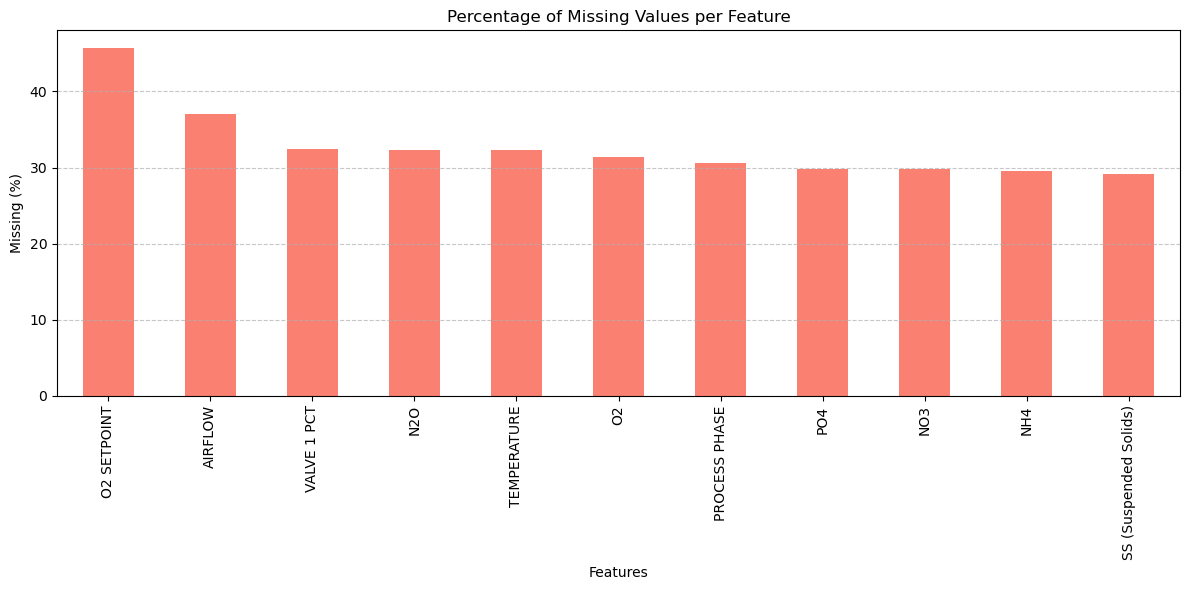

Top 5 columns with missing data:
O2 SETPOINT    45.755084
AIRFLOW        37.000005
VALVE 1 PCT    32.371243
N2O            32.362937
TEMPERATURE    32.360214
dtype: float64


In [11]:
import matplotlib.pyplot as plt

# Visualize Missing Data 

# 1. Calculate the percentage of missing data for each column
missing_percent = df.isna().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)

# 2. Plot the missing data
plt.figure(figsize=(12, 6))
missing_percent.plot(kind='bar', color='salmon')
plt.title("Percentage of Missing Values per Feature")
plt.ylabel("Missing (%)")
plt.xlabel("Features")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Print the worst offenders
print("Top 5 columns with missing data:")
print(missing_percent.head())

# OVERVIEW

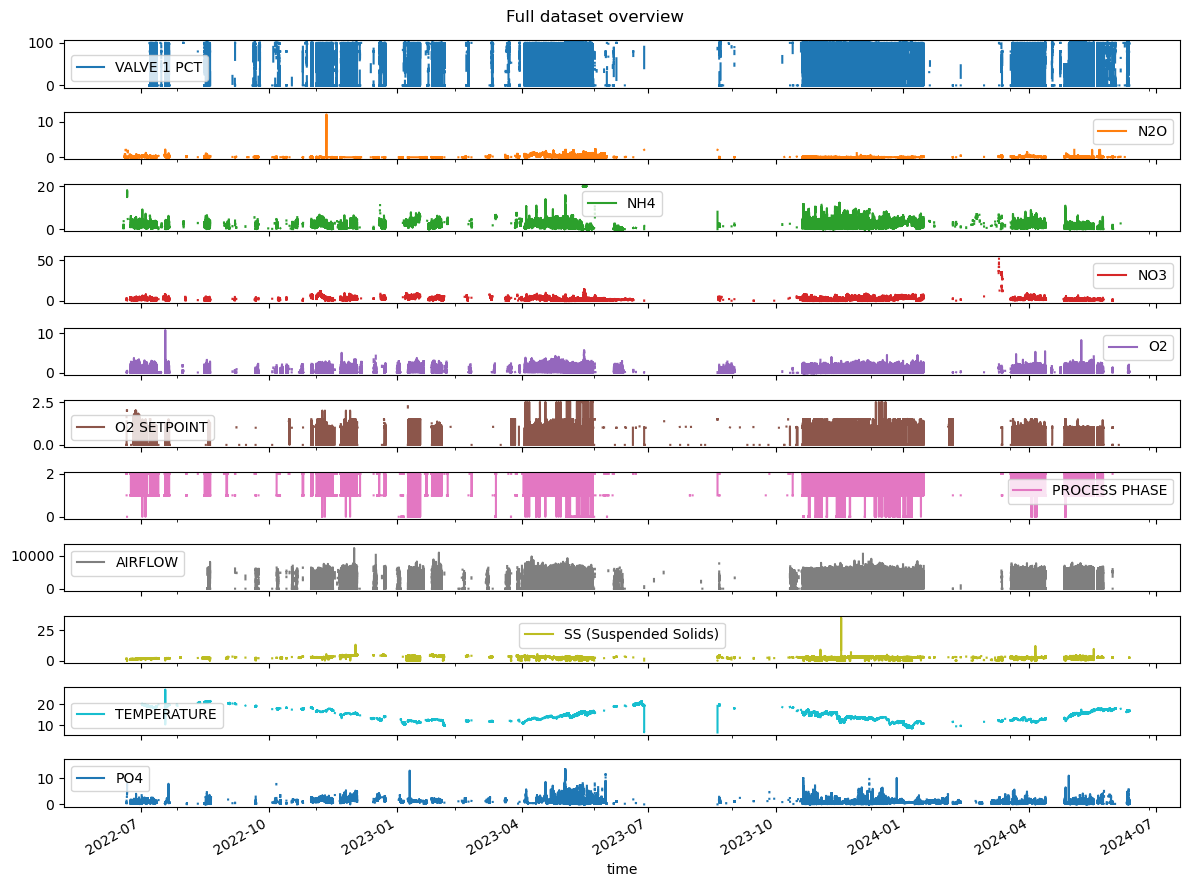

In [12]:
# Overview plot
plot_df = df_vars
plot_df.plot(subplots=True, figsize=(12,9), title="Full dataset overview")
plt.tight_layout()
plt.show()

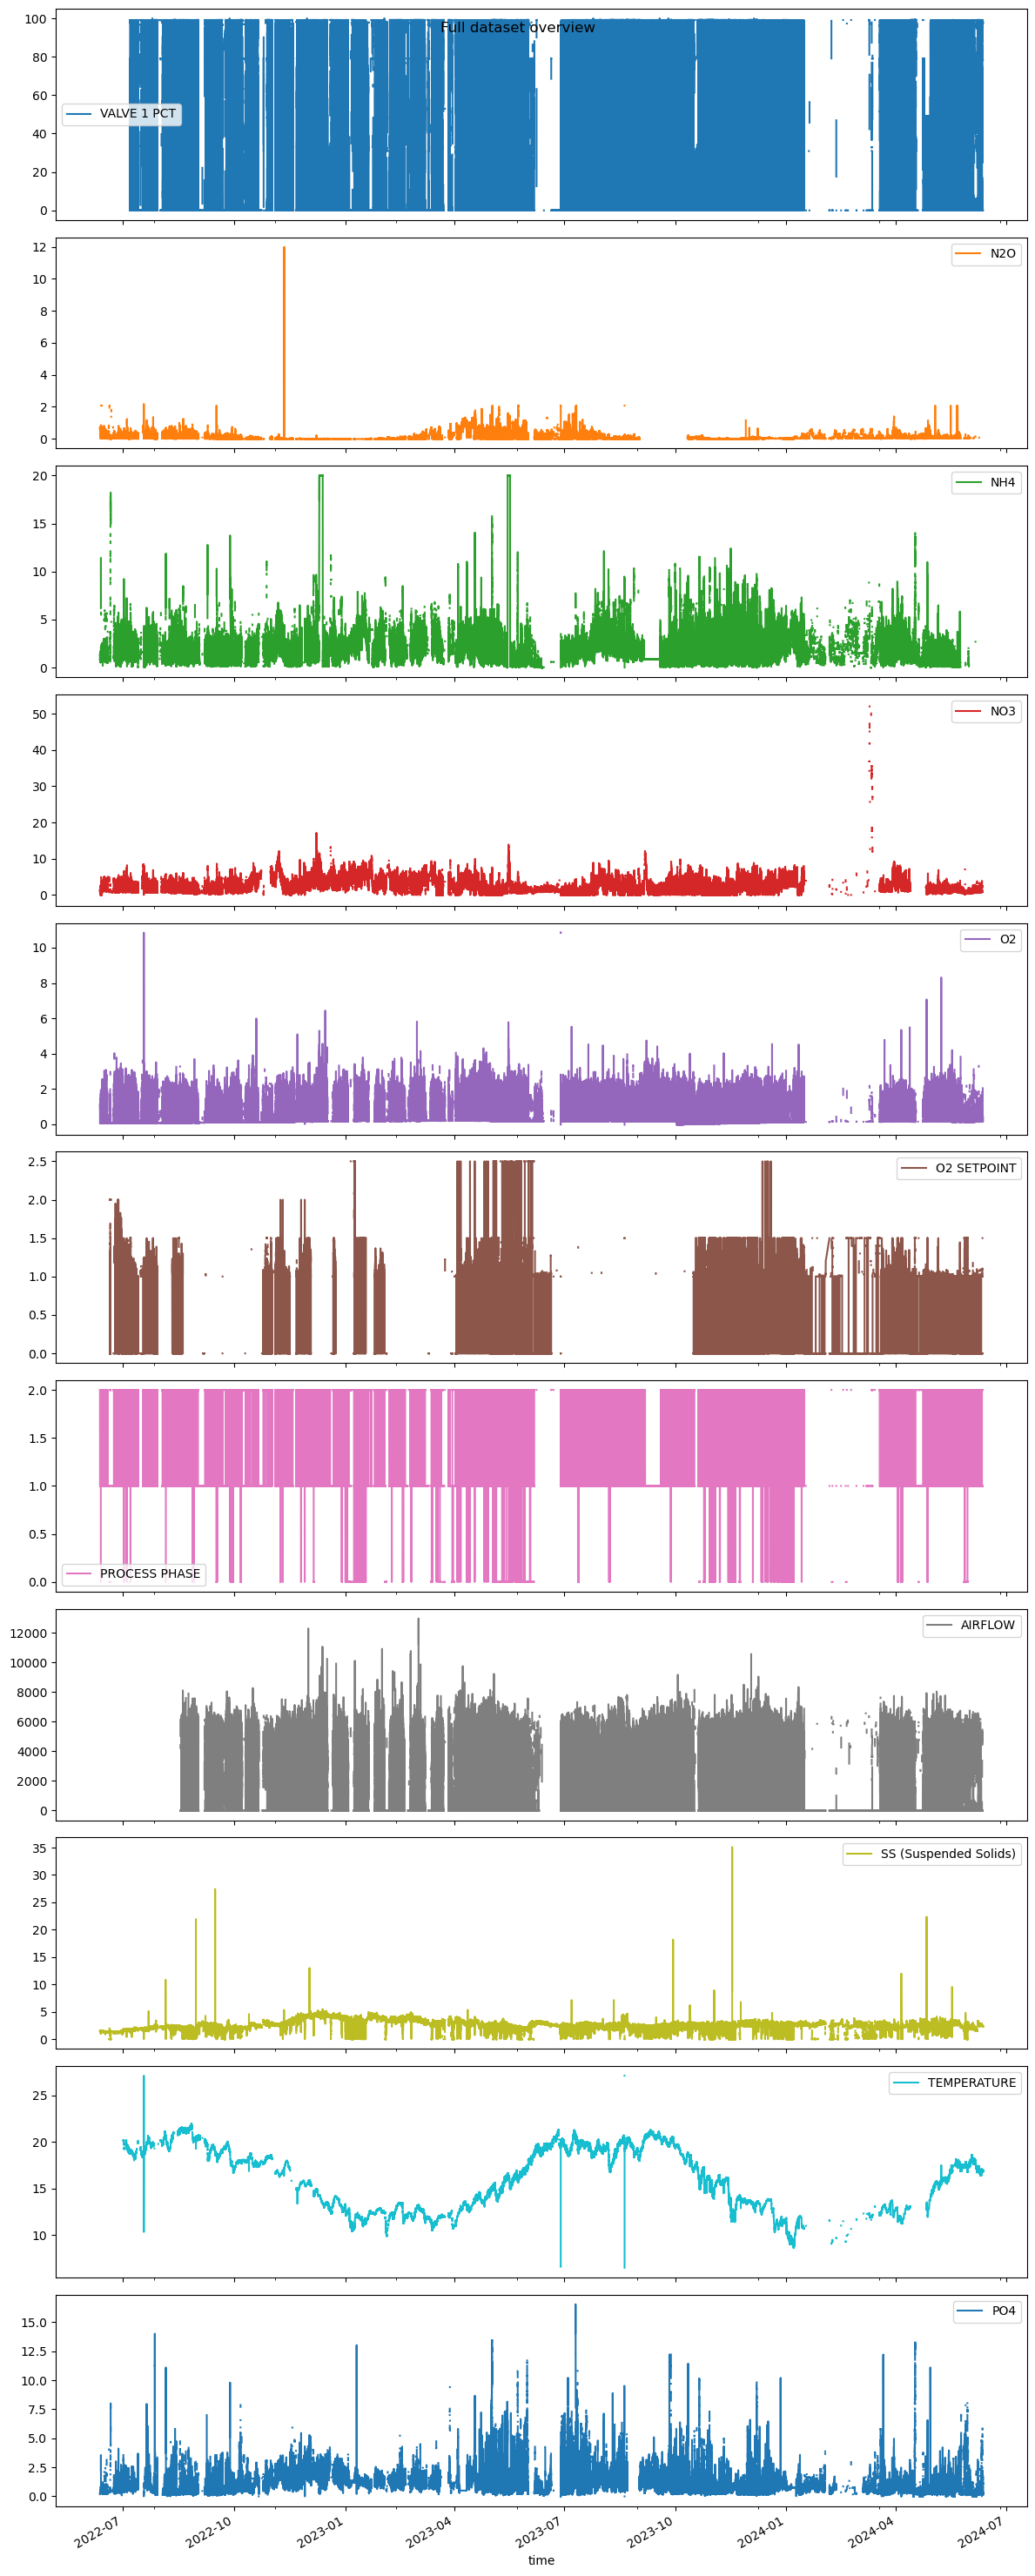

In [13]:
# Overview plot
# We use the cleaned dataframe 'df'
plot_df = df
plot_df.plot(subplots=True, figsize=(12, 30), title="Full dataset overview")
plt.tight_layout()
plt.show()

# EDA

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Statistical Summary
# .T transposes the table to make it vertical and easier to read
display(df_vars.describe().T) 

,count,mean,std,min,25%,50%,75%,max
VALVE 1 PCT,502835.0,44.468405,42.042082,0.000000,0.000000,40.700001,89.199997,100.000000
N2O,520546.0,0.103827,0.240844,-0.023727,-0.008681,0.012731,0.109954,12.000000
NH4,520595.0,2.307532,2.209858,-0.004505,0.947455,1.866794,3.030480,20.007799
NO3,520583.0,2.777697,2.776430,-0.338735,1.179841,2.176571,3.728446,52.658241
O2,520601.0,0.615051,0.612024,-0.035807,0.152995,0.326968,0.989945,10.850695
O2 SETPOINT,526285.0,0.627683,0.573422,0.000000,0.000000,1.000000,1.036053,2.500000
PROCESS PHASE,519349.0,1.501077,0.583287,0.000000,1.000000,2.000000,2.000000,2.000000
AIRFLOW,470203.0,2188.748704,2133.804365,0.000000,0.000000,2165.943981,4019.957266,12973.047180
SS (Suspended Solids),520589.0,2.552868,0.862651,0.000000,2.137634,2.550476,2.964663,35.092827
TEMPERATURE,506607.0,15.659757,3.380248,6.488715,12.618454,15.634042,18.901005,27.126736


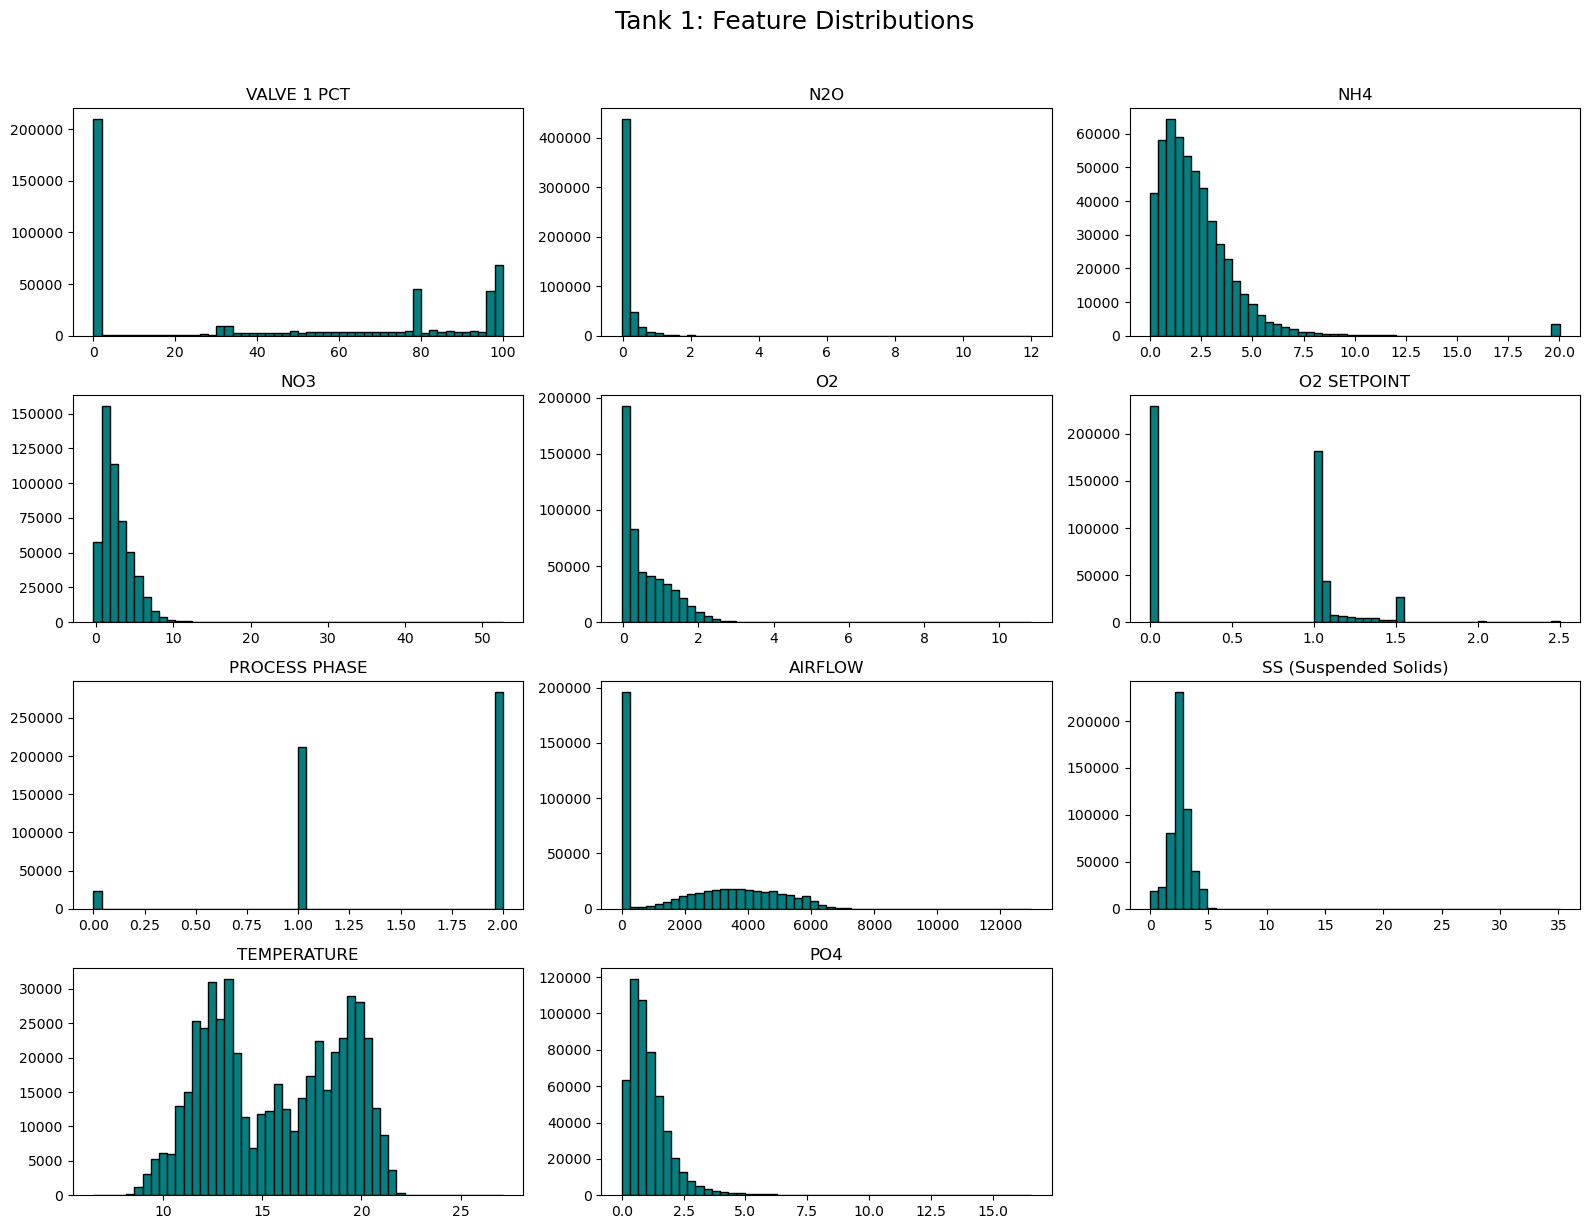

In [44]:
#Feature Distributions (Histograms)
# We use figsize=(16, 12) to give the 11 plots enough room to breathe
df_vars.hist(bins=50, figsize=(16, 12), color='teal', edgecolor='black', grid=False)
plt.suptitle("Tank 1: Feature Distributions", y=1.02, fontsize=18)
plt.tight_layout()
plt.show()

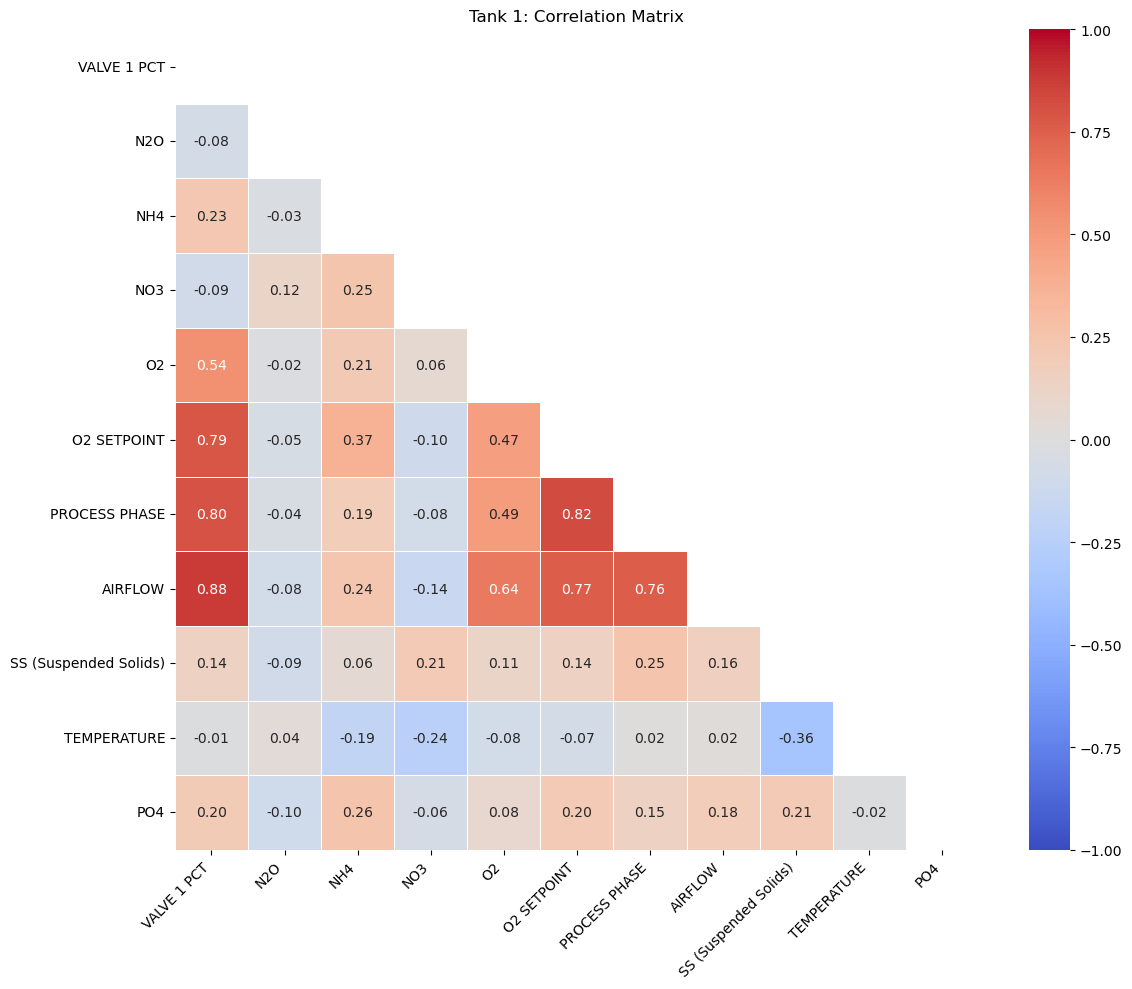

In [45]:
#Correlation Matrix (Heatmap)
plt.figure(figsize=(12, 10))

# Calculate the correlation matrix
corr_matrix = df_vars.corr()

# Mask the upper triangle to make it cleaner (avoids duplicate info)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the heatmap (we add annot=True to see the exact numbers!)
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, 
            annot=True, fmt=".2f", linewidths=0.5)

plt.title("Tank 1: Correlation Matrix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Original features count: 11
Features after selection: 9

Final Selected Features:
 - N2O
 - NH4
 - NO3
 - O2
 - PROCESS PHASE
 - AIRFLOW
 - SS (Suspended Solids)
 - TEMPERATURE
 - PO4


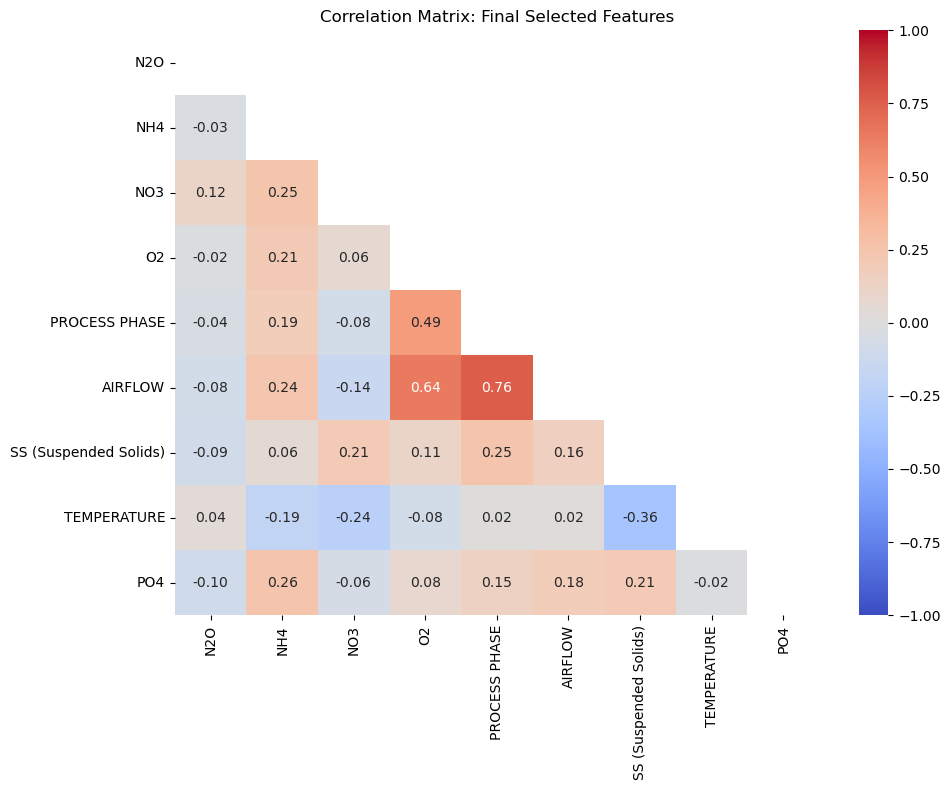

In [46]:
print(f"Original features count: {df_vars.shape[1]}")

# Define the features we want to drop because of high redundancy (Correlation > 0.8)
features_to_drop = [
    "VALVE 1 PCT",   # Redundant with AIRFLOW (corr ~ 0.90)
    "O2 SETPOINT"    # Redundant target, we care about actual O2 and AIRFLOW
]

# Create the final selected dataframe
df_selected = df_vars.drop(columns=features_to_drop).copy()

print(f"Features after selection: {df_selected.shape[1]}")
print("\nFinal Selected Features:")
for col in df_selected.columns:
    print(f" - {col}")

# Quick check of the new, cleaner correlation matrix
plt.figure(figsize=(10, 8))
corr_selected = df_selected.corr()
mask = np.triu(np.ones_like(corr_selected, dtype=bool))
sns.heatmap(corr_selected, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, annot=True, fmt=".2f")
plt.title("Correlation Matrix: Final Selected Features")
plt.tight_layout()
plt.show()

# PHYSICAL CHOICE

The Variables Kept by Professor (The "Nitrogen Story")
The professor isolated the exact variables needed to model **Nitrification/Denitrification** (how bacteria clean nitrogen from water) and its side effects:

- NH4 (Ammonium) & NO3 (Nitrate) (The Core Process): These are the main chemical pollutants the plant is trying to remove. Bacteria eat NH4 and convert it into NO3 (Nitrification), and then convert NO3 into harmless nitrogen gas (Denitrification). We must track these to know if the water is getting clean.

- N2O (Nitrous Oxide) (The Target): N2O is a massive greenhouse gas (300x worse than CO2). In modern environmental engineering, predicting and minimizing N2O emissions is a huge research topic. It is produced as a side-effect when NH4 and NO3 are processed.

- Airflow (The Control Knob): This is the main thing the plant operators can actually control. Pumping air provides oxygen for the bacteria to eat the NH4.

- Temperature (The Environment): Bacteria are highly sensitive to temperature. They eat fast in summer and slow in winter. We can't control it, but the model needs to know it to predict the reaction speed so we may have to add this.

Why we remove the OTHERS?

- Airflow Cause DO 
If you know the Airflow and the Temperature, you basically know the O2.
Keeping Airflow is better because it represents the actual energy the plant is spending so we can Remove O2

- PO4 is part of the Phosphorus cycle, not the Nitrogen cycle. It doesn't heavily interact with NH4, NO3, or N2O. So we can drop it

- PROCESS PHASE : We don't need a variable to tell what "Phase" the tank is in, because Airflow already tells you. If Airflow > 0, you are in the Aeration phase.
If Airflow == 0, you are in the resting/Anoxic phase. So PROCESS PHASE is redundant.

- SS represents the total mass of bacteria in the tank. This changes very, very slowly (over weeks or months). Because our dataset is measuring minute-by-minute dynamics (like sudden air bursts), SS is basically a flat line compared to the others and doesn't add much value to short-term predictions.

# KEEPING OUR FEATURES

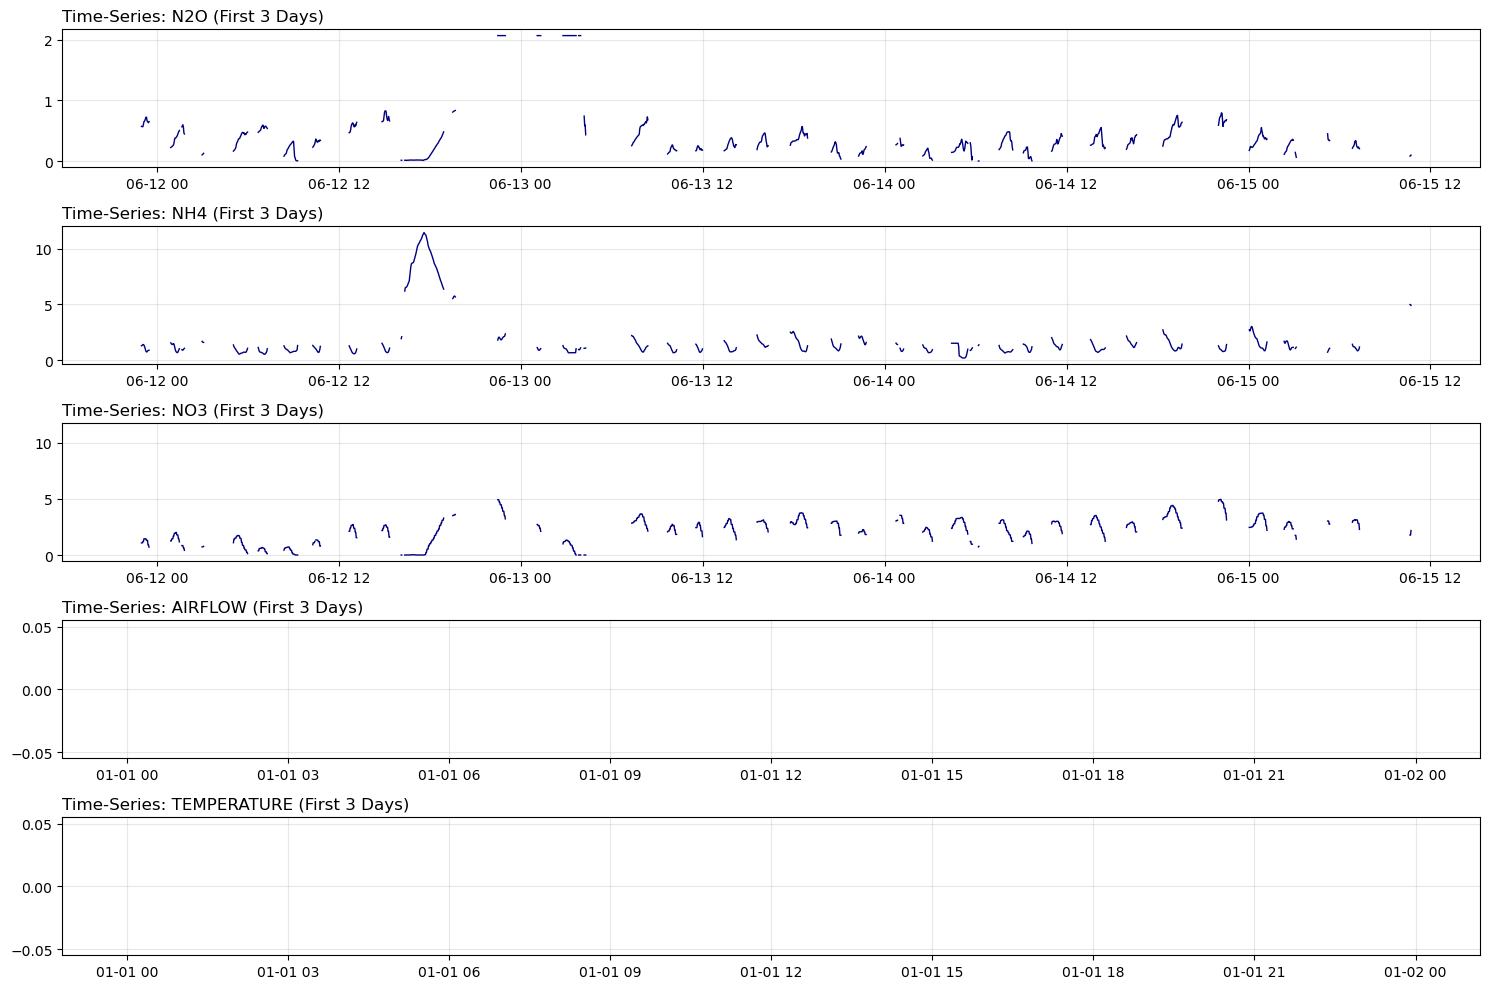

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure we are only using the 5 features your professor selected!
target_cols = ["N2O", "NH4", "NO3", "AIRFLOW", "TEMPERATURE"]
df_final = df[target_cols].copy()

#Time-Series "Zoom" Plot
plt.figure(figsize=(15, 10))

# We slice the first 3 days of valid data so the plot isn't a solid block of ink
df_subset = df_final.head(4320) # Approx 3 days at 1-minute intervals

for i, col in enumerate(df_final.columns, 1):
    plt.subplot(5, 1, i)
    plt.plot(df_subset.index, df_subset[col], color='navy', linewidth=1)
    plt.title(f"Time-Series: {col} (First 3 Days)", loc='left', fontsize=12)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

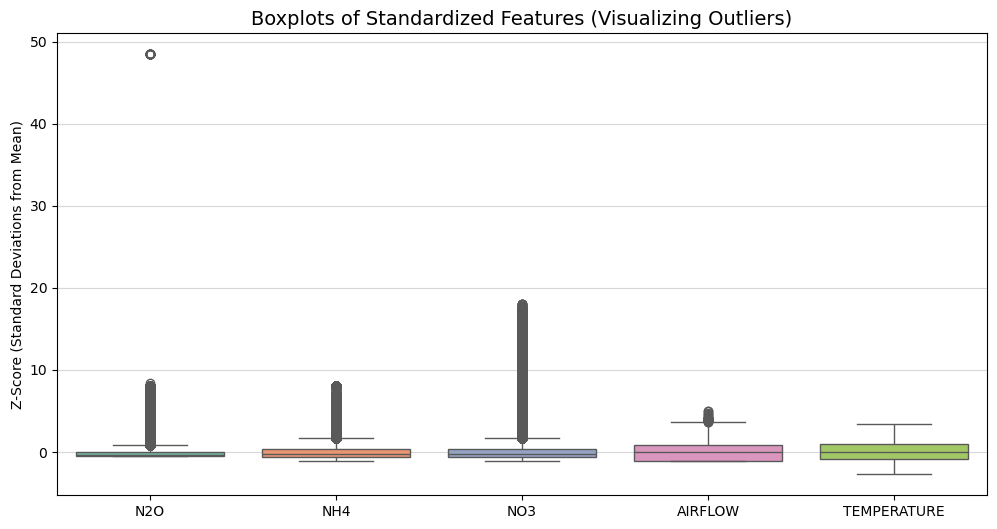

In [48]:
#Standardized Boxplots
plt.figure(figsize=(12, 6))

# We "Standardize" the data (Z-Score) so they all fit on the same Y-axis scale
# Otherwise, Airflow (e.g., 20,000) would crush N2O (e.g., 0.5) making it invisible
df_normalized = (df_final - df_final.mean()) / df_final.std()

sns.boxplot(data=df_normalized, palette="Set2")
plt.title("Boxplots of Standardized Features (Visualizing Outliers)", fontsize=14)
plt.ylabel("Z-Score (Standard Deviations from Mean)")
plt.grid(axis='y', alpha=0.5)
plt.show()

there are extreme outliers. The plot is forced to zoom so far out to fit one crazy data point

EXAMPLE in N20 with outlier at around 50 


Plotting Individual Boxplots for the Final 5 Features


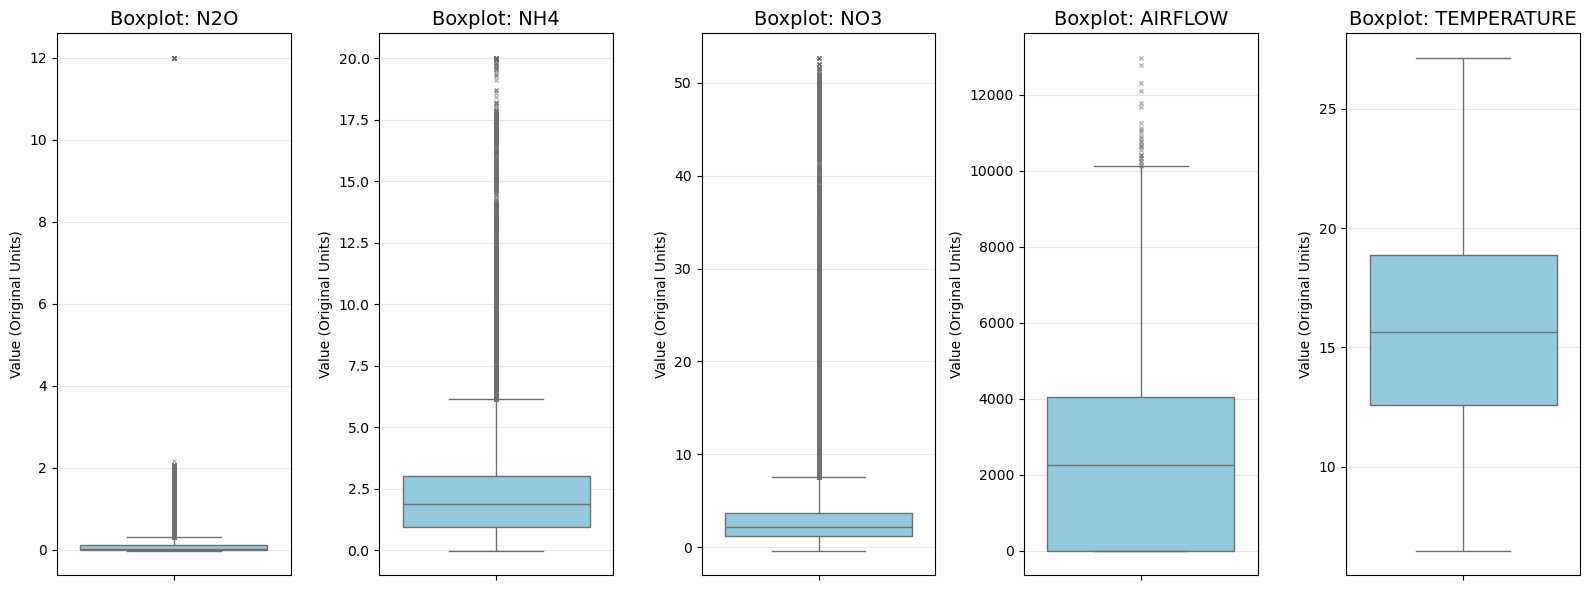

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Plotting Individual Boxplots for the Final 5 Features")

# We create a plot with 1 row and 5 columns
plt.figure(figsize=(16, 6))

for i, col in enumerate(df_final.columns, 1):
    plt.subplot(1, 5, i)
    
    # We plot each feature on its own Y-axis so it doesn't get crushed by Airflow
    sns.boxplot(y=df_final[col], color="skyblue", 
                flierprops={"marker": "x", "markersize": 3, "alpha": 0.5})
    
    plt.title(f"Boxplot: {col}", fontsize=14)
    plt.ylabel("Value (Original Units)")
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

The Box (The Middle 50%): The colored box shows where the vast majority of your normal, everyday data lives. 

The Line Inside the Box (The Median): This is the exact middle value of your dataset.

The "Whiskers" (The T-shaped lines): These extend out to show the "expected range" of your data. Anything inside the whiskers is considered normal.

The Dots / X's (The Outliers!): This is what you care about. Any dot that exists outside of the whiskers is a statistical anomaly

NH4 N02 and NO3 are extremely skewed: Their boxes are tiny and sit at the very bottom, but they have a massive trail of outlier dots shooting straight up. This proves that 90% of the time, the chemical concentrations are very low (near zero), but occasionally there is a massive toxic spike (like a sudden influx of ammonia into the plant).

Airflow has two modes: The airflow box is huge and covers almost the whole range. This is because airflow is either fully ON (around 30,000) or fully OFF (0).
There are very few "outliers" for airflow because it operates within a fixed mechanical limit.

Temperature has sensor errors: 

In Temp dots that are way too low (e.g., $0^\circ\text{C}$ inside a heated biological tank) or way too high. **These are pure sensor glitches that We need to remove!**

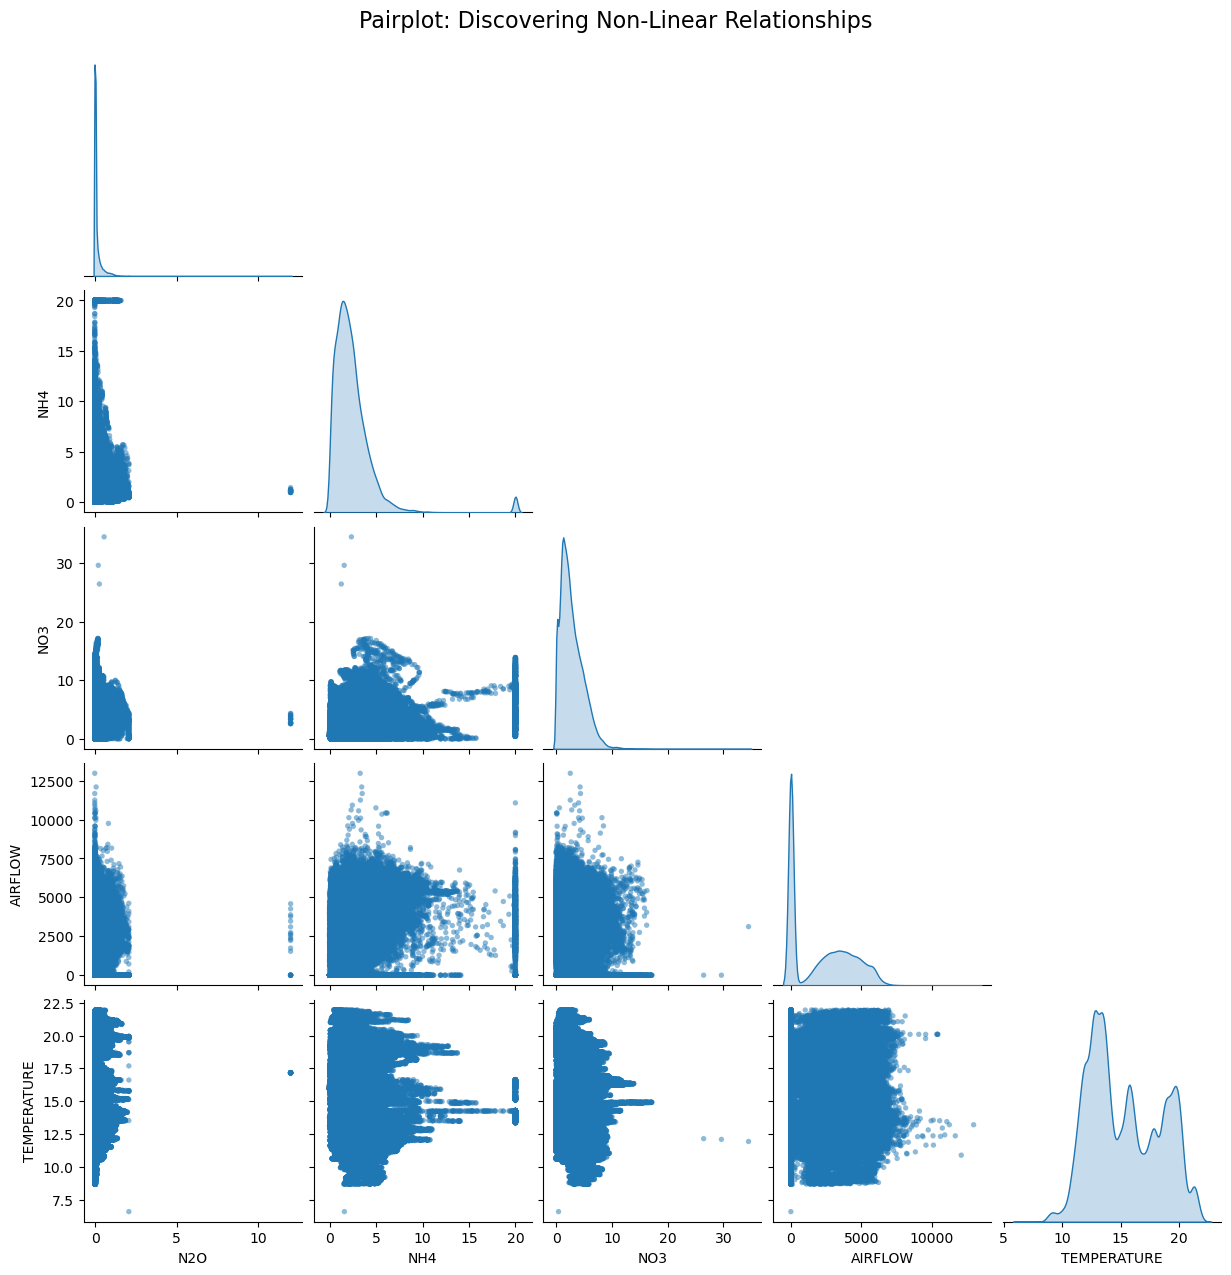

In [50]:
#Pairplot (Scatter Matrix)
# RANDOM SAMPLE ON 200000 dots because it will crash my computer if I do all.
df_sample = df_final.dropna().sample(n=200000, random_state=42)

# corner=True removes duplicate plots. diag_kind='kde' shows the smooth distribution shape.
sns.pairplot(df_sample, diag_kind='kde', corner=True, 
             plot_kws={'alpha': 0.5, 's': 15, 'edgecolor': 'none'})
plt.suptitle("Pairplot: Discovering Non-Linear Relationships", y=1.02, fontsize=16)
plt.show()

# On ALL VARIABLE TANK1

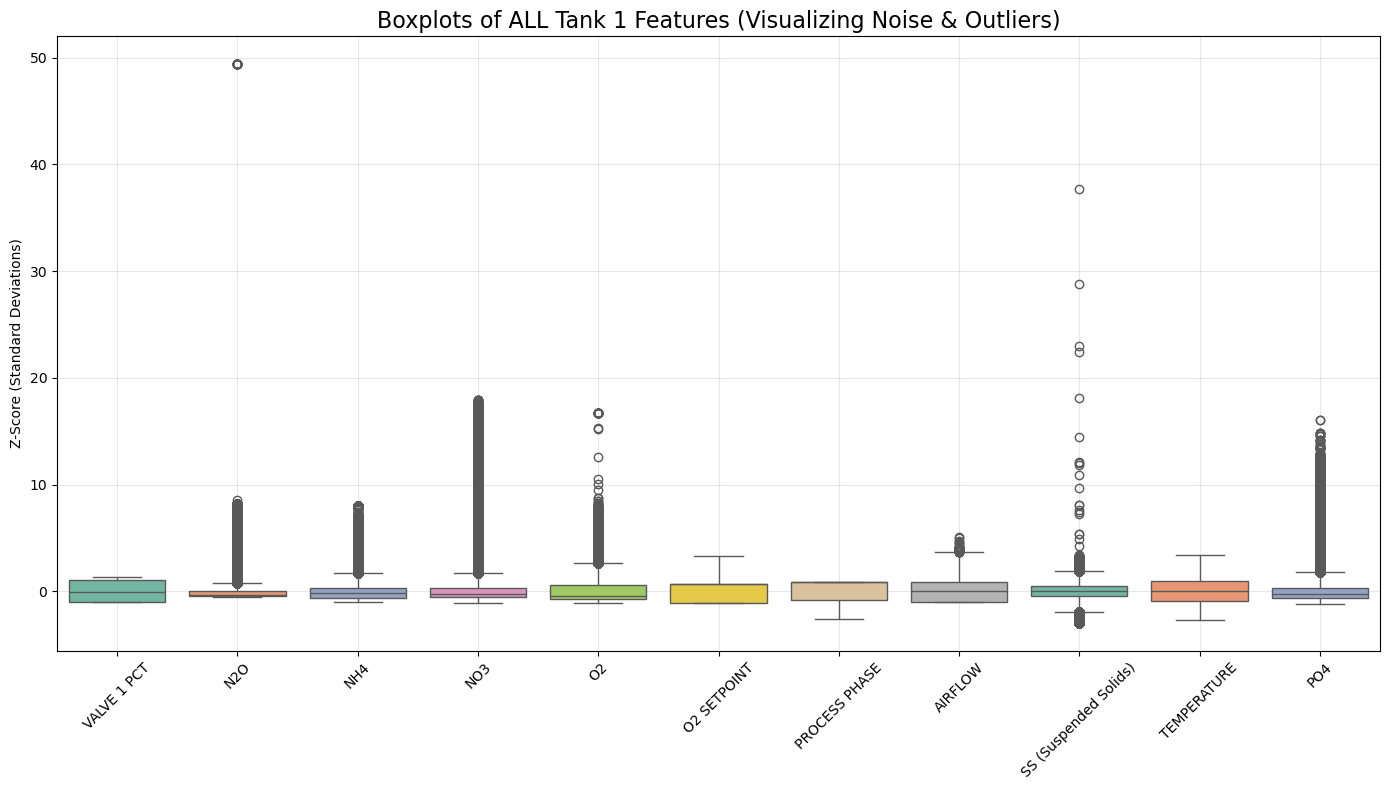

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Make sure we have our 11 Tank 1 variables loaded as df_vars
df_all_11 = df_vars.copy()

plt.figure(figsize=(14, 8))
# Standardize (Z-score) so we can see all variables on the same Y-axis scale
df_normalized = (df_all_11 - df_all_11.mean()) / df_all_11.std()

sns.boxplot(data=df_normalized, palette="Set2")
plt.title("Boxplots of ALL Tank 1 Features (Visualizing Noise & Outliers)", fontsize=16)
plt.ylabel("Z-Score (Standard Deviations)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

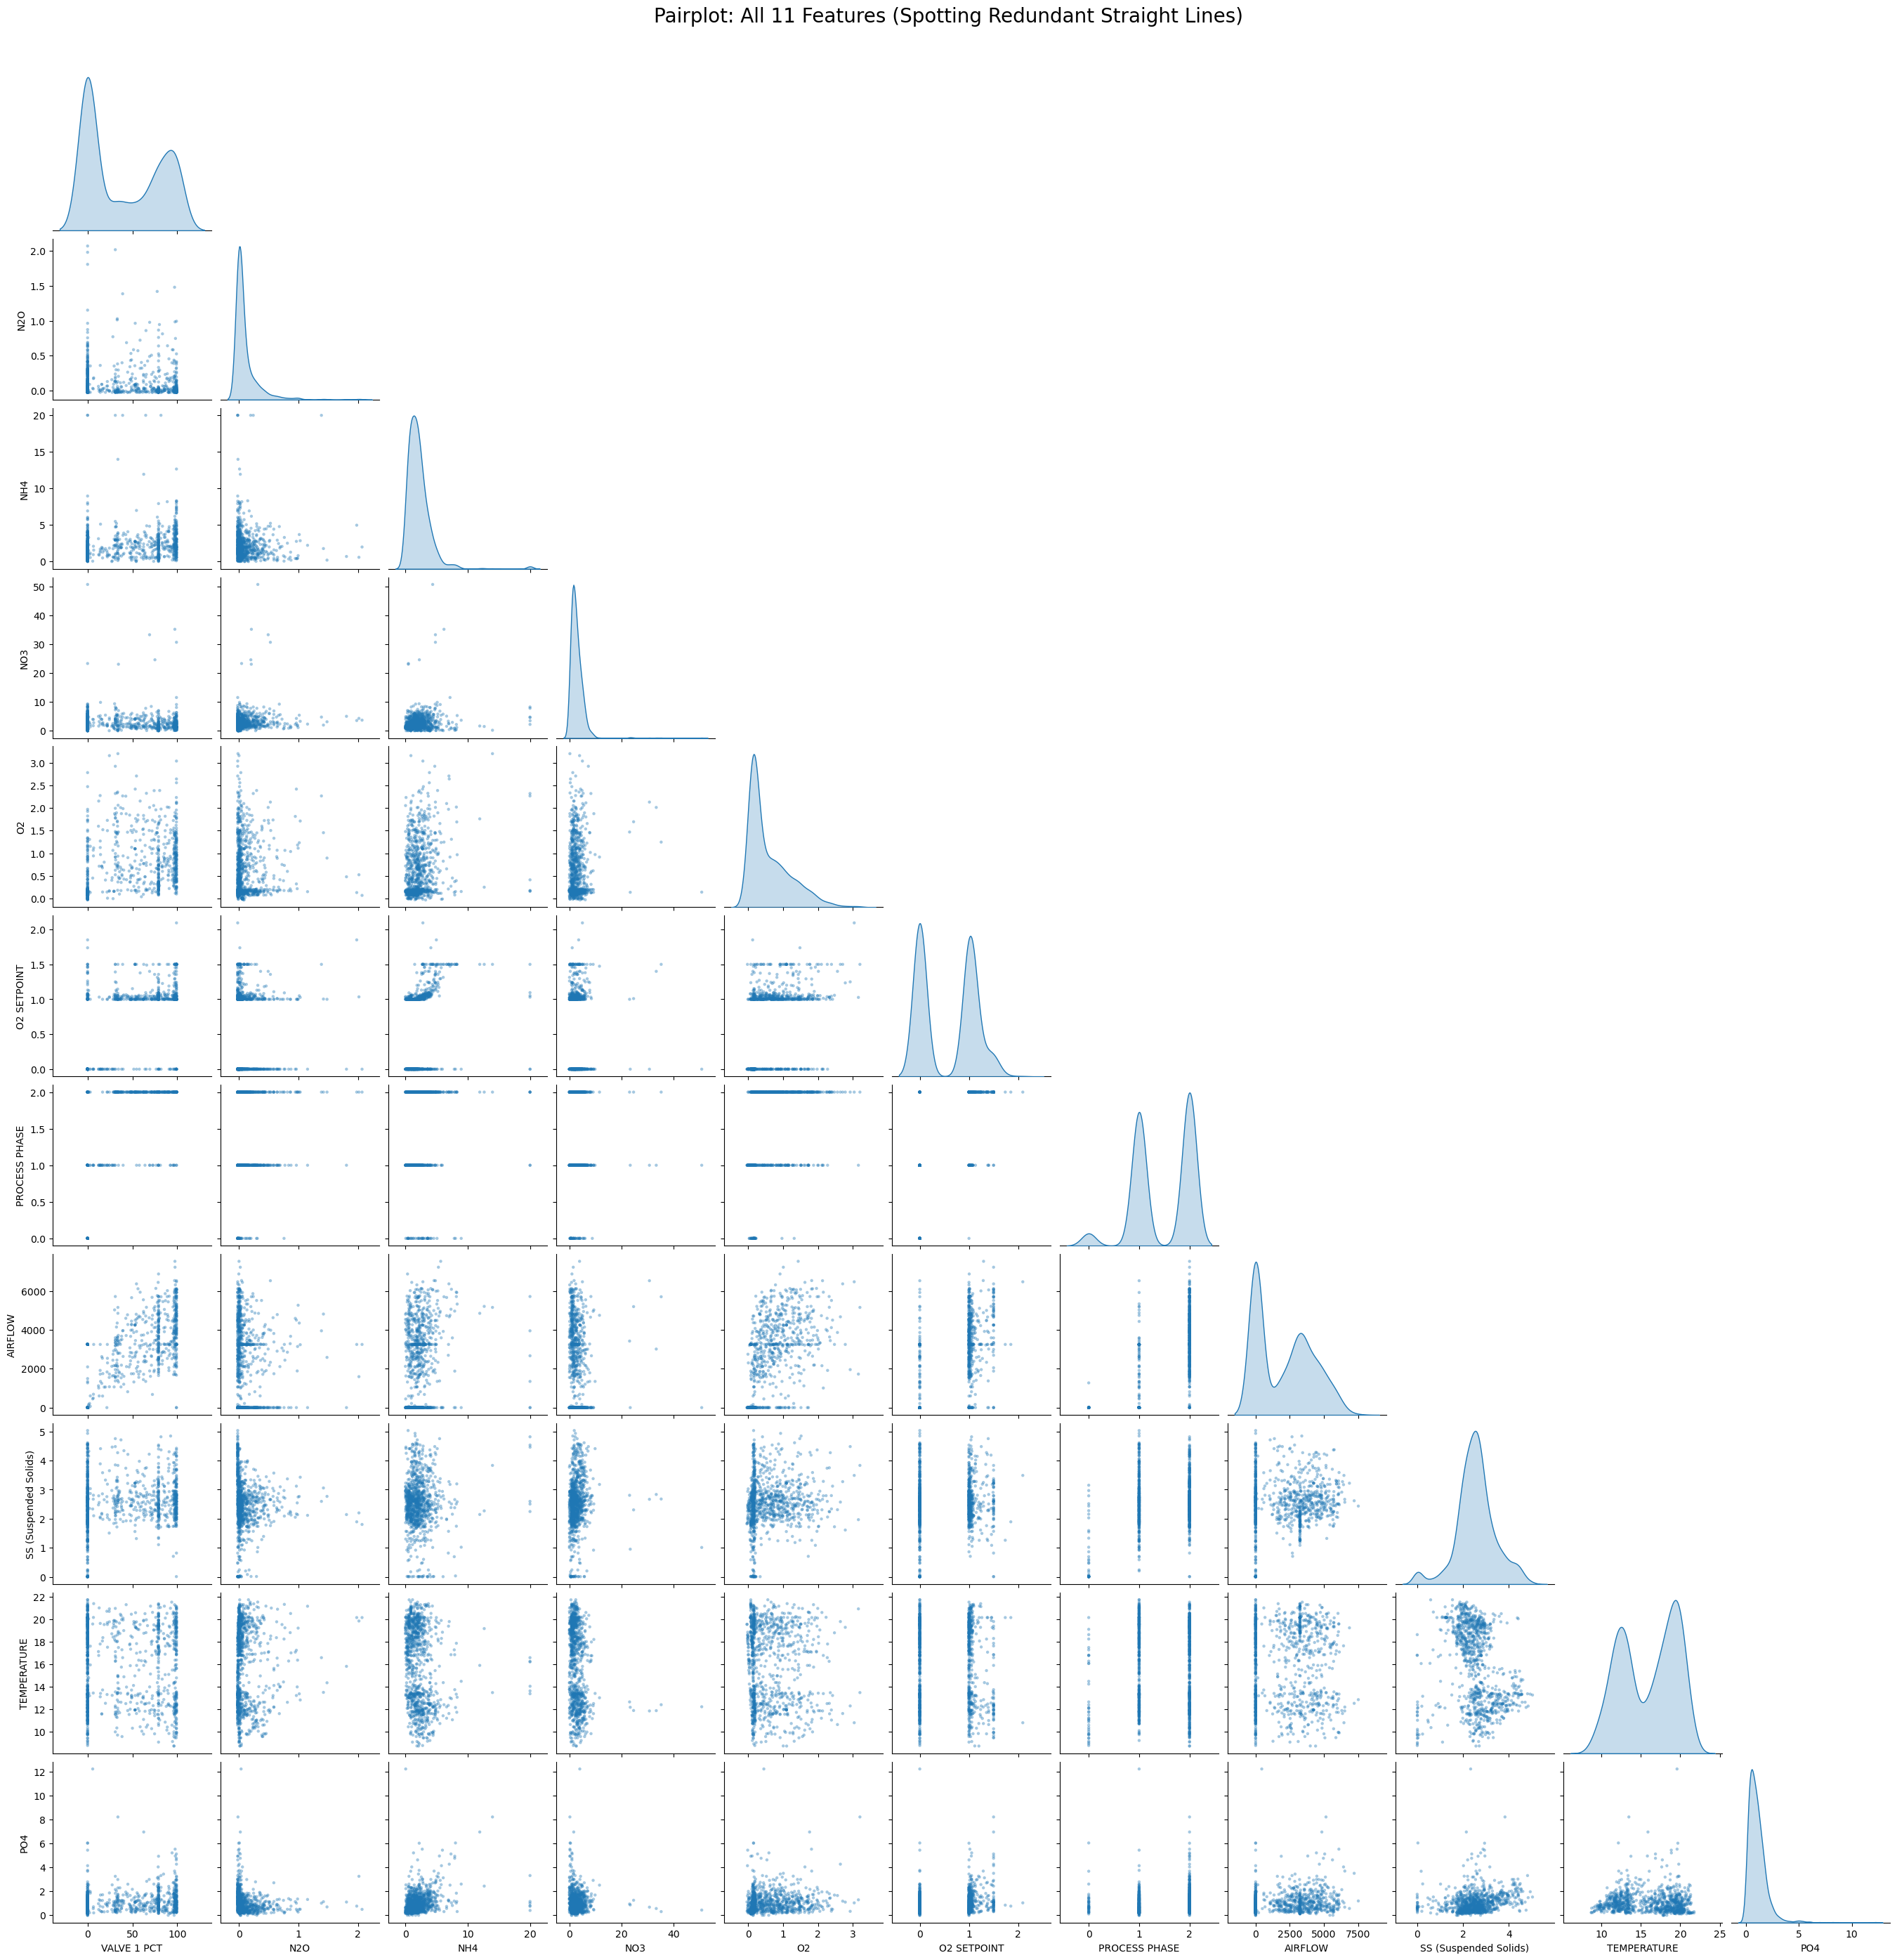

In [52]:
# Because an 11x11 grid is 121 scatter plots, it will crash so i do it with a saple of 1000 random rows
# We forward-fill missing data just for the visual, 
# and sample 1,000 random rows.
df_imputed_for_plot = df_all_11.ffill().bfill()
df_sample = df_imputed_for_plot.sample(n=1000, random_state=42)

# corner=True removes duplicate mirrored plots to save space
g = sns.pairplot(df_sample, diag_kind='kde', corner=True, 
                 plot_kws={'alpha': 0.4, 's': 10, 'edgecolor': 'none'})
g.fig.suptitle("Pairplot: All 11 Features (Spotting Redundant Straight Lines)", y=1.02, fontsize=20)
plt.show()

What it shows: * Linear Redundancy* : The intersections between Mechanical controls (like AIRFLOW vs. VALVE 1 PCT) form straight lines, meaning they are mathematically redundant.

Biological Complexity: The intersections between the chemicals (NH4, NO3, N2O) form scattered, non-linear "clouds." This proves that the biological reactions are highly complex and justifies the need to use advanced Machine Learning models (like Random Forests) rather than simple linear regression.